# Plots for Manuscript

In [ ]:
output_root = # path to where all figures will be saved

### Study Site

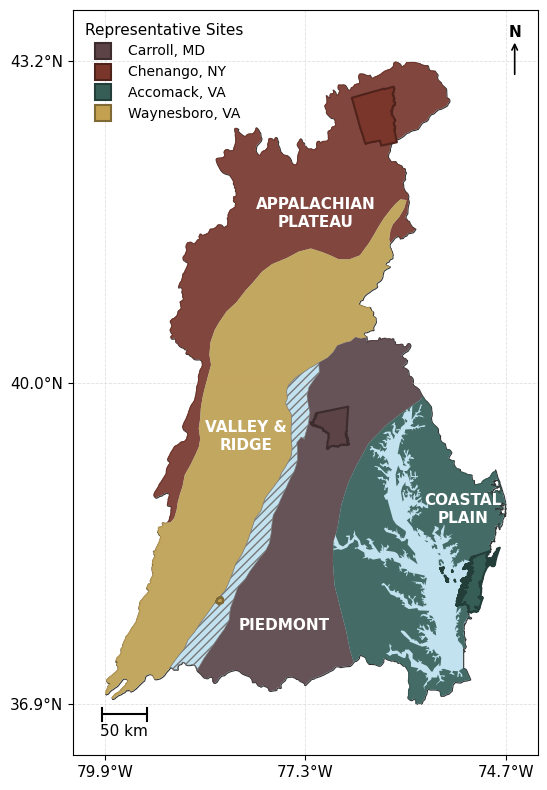

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.colors as mcolors
from pyproj import Transformer

# load data
fp_ws = # path to watershed boundary shapefile
fp_pr = # path to physiographic region shapefule
fp_ls = # path to CAST land segment shapefile

watershed = gpd.read_file(fp_ws)
physio = gpd.read_file(fp_pr)
cast_segments = gpd.read_file(fp_ls)

proj_crs = 'EPSG:5070'
watershed = watershed.to_crs(proj_crs)
physio = physio.to_crs(proj_crs)
cast_segments = cast_segments.to_crs(proj_crs)

physio_of_interest = ['APPALACHIAN PLATEAUS', 'VALLEY AND RIDGE', 'PIEDMONT', 'COASTAL PLAIN', 'BLUE RIDGE']
physio_filtered = physio[physio['PROVINCE'].isin(physio_of_interest)].copy()
physio_dissolved = physio_filtered.dissolve(by='PROVINCE', as_index=False)
physio_clipped = gpd.clip(physio_dissolved, watershed.union_all())

site_fips = [51001, 36017, 24013, 51820]
sites = cast_segments[cast_segments['FIPS'].isin(site_fips)].copy()
sites = sites.dissolve(by='FIPS').reset_index()

fips_to_region = {51001: 'COASTAL PLAIN', 36017: 'APPALACHIAN PLATEAUS', 24013: 'PIEDMONT', 51820: 'VALLEY AND RIDGE'}
sites["region"] = sites["FIPS"].map(fips_to_region)

# style
region_colors = {
    'APPALACHIAN PLATEAUS': '#7A362A',
    'VALLEY AND RIDGE': '#C3A151',
    'PIEDMONT': '#5C4346', 
    'COASTAL PLAIN': '#365E57',
    'BLUE RIDGE': "#ffffff"
}
sites["color"] = sites["region"].map(region_colors)

region_labels = {
    'APPALACHIAN PLATEAUS': 'APPALACHIAN\nPLATEAU',
    'VALLEY AND RIDGE': 'VALLEY &\nRIDGE',
    'PIEDMONT': 'PIEDMONT',
    'COASTAL PLAIN': 'COASTAL\nPLAIN'
}

# format
site_labels = {
    51001: 'Accomack, VA', 
    36017: 'Chenango, NY', 
    24013: 'Carroll, MD', 
    51820: 'Waynesboro, VA'
}

region_positions = {
    'COASTAL PLAIN': (1750010, 1905000),
    'PIEDMONT': (1550000, 1775000),
    'VALLEY AND RIDGE': (1507228, 1986170),
    'APPALACHIAN PLATEAUS': (1585000, 2234681)
}

# fxn for darker site colors
def darken_color(hex_color, amount=0.4):
    try:
        c = mcolors.hex2color(hex_color)
        return mcolors.to_hex([max(0, channel * (1 - amount)) for channel in c])
    except:
        return "#181818" # Fallback if something goes wrong

# plot
fig, ax = plt.subplots(figsize=(6, 8)) 
fig.patch.set_alpha(0) 

xmin, ymin, xmax, ymax = watershed.total_bounds
xpad = (xmax - xmin) * 0.08
ypad = (ymax - ymin) * 0.08
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

# water coloring
watershed.plot(ax=ax, facecolor='#C2E2F0', edgecolor='#333333', linewidth=0.8, zorder=1)

# Physiographic regions
for region, color in region_colors.items():
    subset = physio_clipped[physio_clipped["PROVINCE"] == region]
    if not subset.empty and region != "BLUE RIDGE":
        subset.plot(ax=ax, color=color, edgecolor=None, alpha=0.9, zorder=2)

# exclude blue ridge
blue_ridge = physio_clipped[physio_clipped["PROVINCE"] == "BLUE RIDGE"]
blue_ridge.plot(ax=ax, facecolor='none', edgecolor="#777777", hatch='////', linewidth=0.5, zorder=3)

# plot representative sites with darker edges
for _, row in sites.iterrows():
    base_color = row["color"]
    dark_edge = darken_color(base_color, amount=0.35) # Creates a beautiful, darker blend color
    gpd.GeoSeries(row.geometry).plot(ax=ax, facecolor=base_color, edgecolor=dark_edge, linewidth=1.5, zorder=5)

# region text arrows
for _, row in physio_clipped.iterrows():
    province = row["PROVINCE"]
    if province in region_positions:
        x, y = region_positions[province]
        ax.text(x, y, region_labels[province], fontsize=11, fontweight="bold", 
                ha="center", va="center", color="white", zorder=6)

# legend
legend_elements = []
for _, row in sites.iterrows():
    fips = row["FIPS"]
    base_color = row["color"]
    dark_edge = darken_color(base_color, amount=0.35)
    label = site_labels[fips]
    
    # replicate the marker style for legend
    patch = plt.Line2D([0], [0], marker='s', color='none', 
                       markerfacecolor=base_color, markeredgecolor=dark_edge, 
                       markersize=12, markeredgewidth=1.5, label=label)
    legend_elements.append(patch)

ax.legend(handles=legend_elements, loc='upper left', title="Representative Sites", 
          frameon=False, facecolor=None, edgecolor='#333333', fontsize=10, title_fontsize=11)

# scale bar
scalebar_length = 50000  
scalebar_x = xmin - xpad * 0.1
scalebar_y = ymin - ypad * 0.2
tick_height = (ymax - ymin) * 0.01

ax.plot([scalebar_x, scalebar_x + scalebar_length], [scalebar_y, scalebar_y], color='black', linewidth=1.5, zorder=6)
ax.plot([scalebar_x, scalebar_x], [scalebar_y - tick_height, scalebar_y + tick_height], color='black', linewidth=1.5, zorder=6)
ax.plot([scalebar_x + scalebar_length, scalebar_x + scalebar_length], [scalebar_y - tick_height, scalebar_y + tick_height], color='black', linewidth=1.5, zorder=6)
ax.text(scalebar_x + scalebar_length / 2, scalebar_y - tick_height * 1.5, '50 km', fontsize=11, ha='center', va='top', zorder=6)

# north arrow
ax.annotate('N', xy=(0.95, 0.96), xycoords='axes fraction', fontsize=11, fontweight='bold', ha='center', va='bottom')
ax.annotate('', xy=(0.95, 0.96), xytext=(0.95, 0.91), xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', lw=1.2, color='black'))

# lat/long
ax.grid(True, which='both', color='#E0E0E0', linestyle='--', linewidth=0.6, zorder=0)

x_ticks_m = [xmin, (xmin + xmax)/2, xmax]
y_ticks_m = [ymin, (ymin + ymax)/2, ymax]

transformer = Transformer.from_crs(proj_crs, "EPSG:4326", always_xy=True)

lon_labels = []
for x in x_ticks_m:
    lon, lat = transformer.transform(x, y_ticks_m[1]) 
    lon_labels.append(f"{abs(round(lon, 1))}°W")

lat_labels = []
for y in y_ticks_m:
    lon, lat = transformer.transform(x_ticks_m[1], y) 
    lat_labels.append(f"{round(lat, 1)}°N")

ax.set_xticks(x_ticks_m)
ax.set_yticks(y_ticks_m)
ax.set_xticklabels(lon_labels, fontsize=11)
ax.set_yticklabels(lat_labels, fontsize=11)

ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

plt.tight_layout()
plt.savefig(output_root+'watershed_map.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

### Climate

#### boxplots

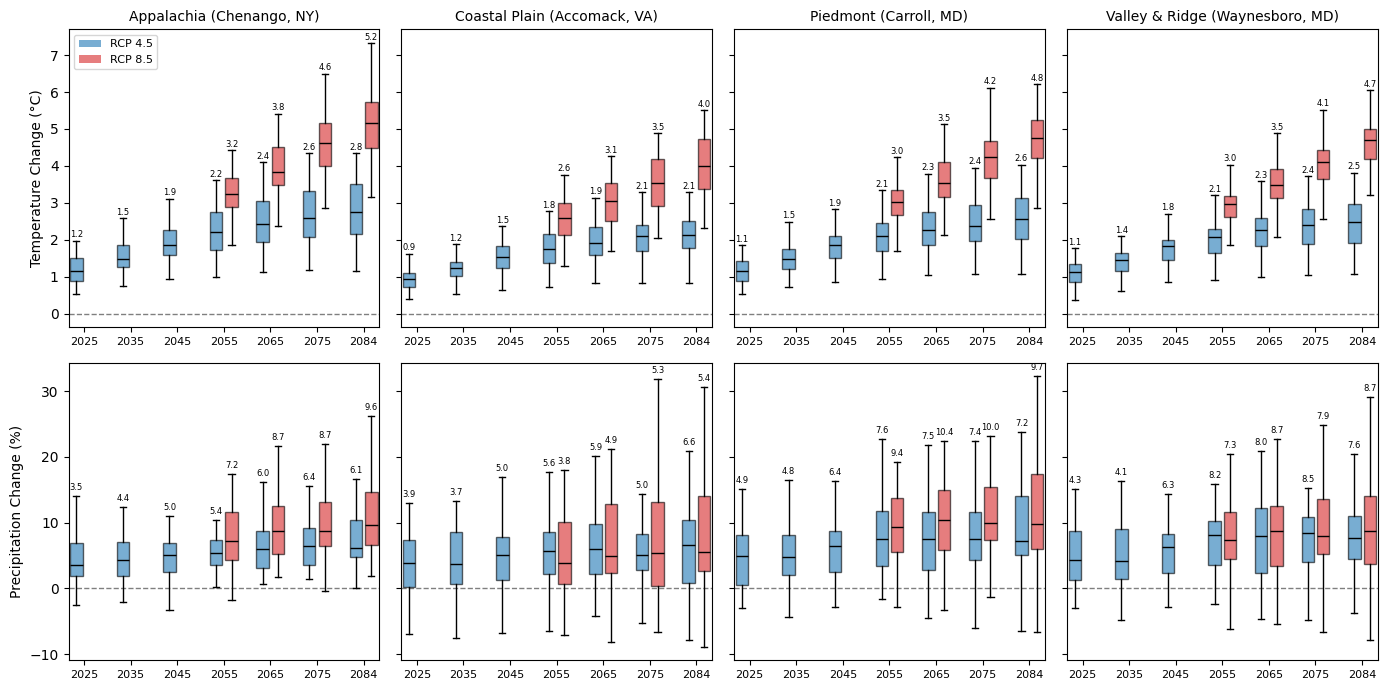

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np


df = pd.read_csv('/path/to/all_deltas_summary.csv')

df['rcp'] = df['filename'].str.extract(r'(RCP[48]5)')
df['period'] = df['filename'].str.extract(r'(\d{4}_\d{4})')
df['midpoint'] = df['period'].apply(lambda x: (int(x.split('_')[0]) + int(x.split('_')[1])) / 2)

regions = ['N36017','N51001', 'N24013', 'N51820']
region_labels = {
    'N36017': 'Appalachia (Chenango, NY)',
    'N51001': 'Coastal Plain (Accomack, VA)',
    'N24013': 'Piedmont (Carroll, MD)', 
    'N51820': 'Valley & Ridge (Waynesboro, MD)'
}


colors = {'RCP45': '#1f77b4', 'RCP85': '#d62728'}

fig, axes = plt.subplots(2, 4, figsize=(14, 7), sharey='row')

for col, region in enumerate(regions):
    for row, var in enumerate(['temp', 'precip']):
        ax = axes[row, col]
        
        subset = df[(df['FIPS_NHL'] == region) & (df['variable'] == var)]
        
        # Get unique midpoints and RCPs, sorted
        midpoints = sorted(subset['midpoint'].unique())
        
        # Build data for boxplot
        positions = []
        data = []
        box_colors = []
        
        for i, mid in enumerate(midpoints):
            for j, rcp in enumerate(['RCP45', 'RCP85']):
                vals = subset[(subset['midpoint'] == mid) & (subset['rcp'] == rcp)]['Total']
                if len(vals) > 0:
                    data.append(vals.values)
                    positions.append(i * 3 + j)  # offset RCPs slightly
                    box_colors.append(colors[rcp])
        
        bp = ax.boxplot(data, positions=positions, widths=0.8, patch_artist=True, showfliers=False)

        for median in bp['medians']:
            median.set_color('black')

        for patch, color in zip(bp['boxes'], box_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)

        # Get whisker tops from the boxplot object
        whisker_tops = [cap.get_ydata()[0] for cap in bp['caps'][1::2]]  # every other cap is the top

        for k, pos in enumerate(positions):
            median_val = np.median(data[k])
            whisker_top = whisker_tops[k]
            offset = 0.09 if var == 'temp' else 0.9
            ax.text(pos, whisker_top + offset, f'{median_val:.1f}', ha='center', fontsize=6)

        ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
        
        # X-axis labels
        ax.set_xticks([i * 3 + 0.5 for i in range(len(midpoints))])
        ax.set_xticklabels([int(m) for m in midpoints], fontsize=8)
        
        if row == 0:
            ax.set_title(region_labels[region], fontsize=10)
        if col == 0:
            ylabel = 'Temperature Change (°C)' if var == 'temp' else 'Precipitation Change (%)'
            ax.set_ylabel(ylabel, fontsize=10)
        if row == 0 and col == 0:
            from matplotlib.patches import Patch
            legend_elements = [Patch(facecolor=colors['RCP45'], alpha=0.6, label='RCP 4.5'),
                               Patch(facecolor=colors['RCP85'], alpha=0.6, label='RCP 8.5')]
            ax.legend(handles=legend_elements, loc='upper left', fontsize=8)


plt.tight_layout()
plt.savefig(output_root + 'climate_delta_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

#### line

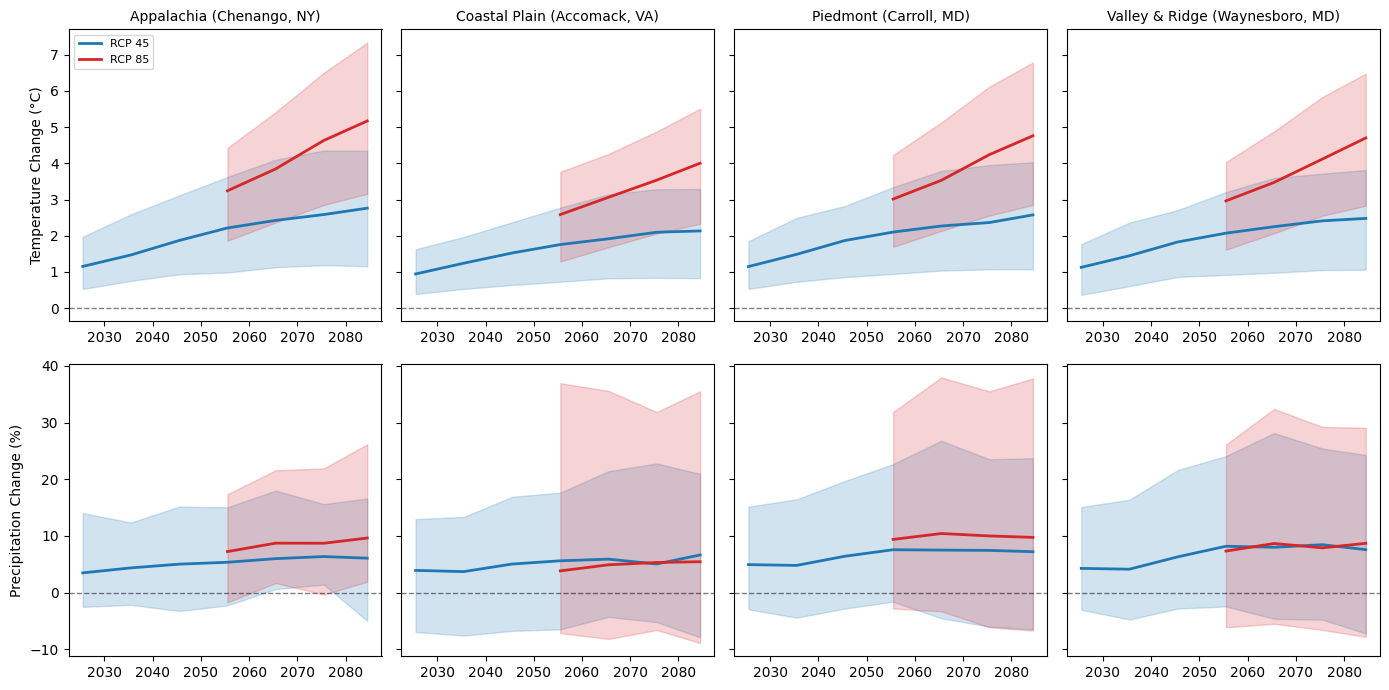

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('path/to/all_deltas_summary.csv')

# Parse filename
df['rcp'] = df['filename'].str.extract(r'(RCP[48]5)')
df['period'] = df['filename'].str.extract(r'(\d{4}_\d{4})')

# Calculate midpoint year
df['midpoint'] = df['period'].apply(lambda x: (int(x.split('_')[0]) + int(x.split('_')[1])) / 2)

regions = ['N36017','N51001', 'N24013', 'N51820']
region_labels = {
    'N36017': 'Appalachia (Chenango, NY)',
    'N51001': 'Coastal Plain (Accomack, VA)',
    'N24013': 'Piedmont (Carroll, MD)', 
    'N51820': 'Valley & Ridge (Waynesboro, MD)'
}

fig, axes = plt.subplots(2, 4, figsize=(14, 7), sharey='row')
colors = {'RCP45': '#1f77b4', 'RCP85': '#d62728'}

for col, region in enumerate(regions):
    for row, var in enumerate(['temp', 'precip']):
        ax = axes[row, col]
        
        for rcp in ['RCP45', 'RCP85']:
            subset = df[(df['FIPS_NHL'] == region) & (df['variable'] == var) & (df['rcp'] == rcp)]
            
            if len(subset) == 0:
                continue
            
            # Group by midpoint and get stats across GCMs
            stats = subset.groupby('midpoint')['Total'].agg(['min', 'median', 'max']).reset_index()
            stats = stats.sort_values('midpoint')
            
            # Plot median line
            ax.plot(stats['midpoint'], stats['median'], color=colors[rcp], 
                    label=rcp.replace('RCP', 'RCP '), linewidth=2)
            
            # Plot shaded range (min to max across GCMs)
            ax.fill_between(stats['midpoint'], stats['min'], stats['max'], 
                           color=colors[rcp], alpha=0.2)
        
        ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
        
        if row == 0:
            ax.set_title(region_labels[region], fontsize=10)
        if col == 0:
            ylabel = 'Temperature Change (°C)' if var == 'temp' else 'Precipitation Change (%)'
            ax.set_ylabel(ylabel, fontsize=10)
        if row == 0 and col == 0:
            ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(output_root + 'climate_delta_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

### Sobol

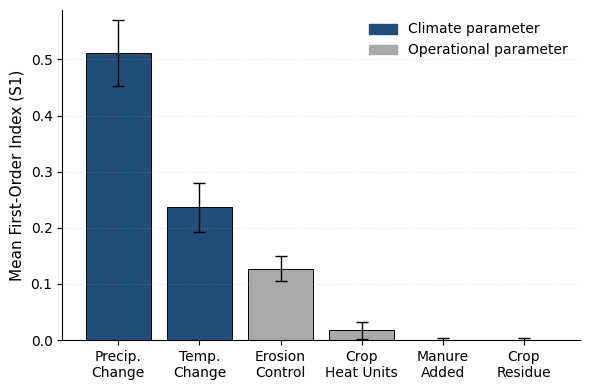

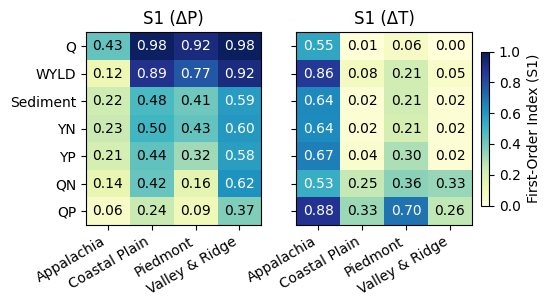

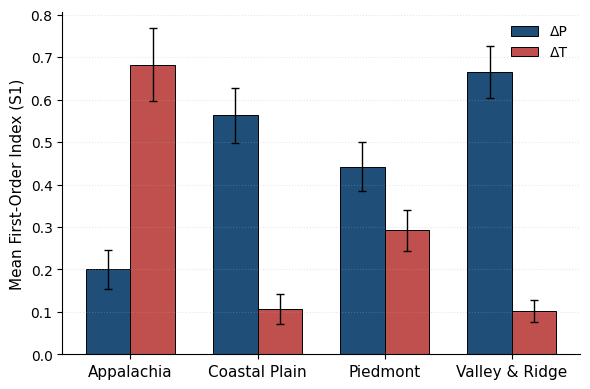

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r'/path/to/all_sobol.csv')

single = df[~df['parameter'].str.contains('x', na=False)].copy()

# FIGURE 1 (MAIN TEXT): Mean S1 by parameter, with CI whiskers
param_order = ['delta_p','delta_t','pec','phu','manure_incorp','residue']
param_labels = {'delta_p':'Precip.\nChange','delta_t':'Temp.\nChange','pec':'Erosion\nControl','phu':'Crop\nHeat Units',
                'manure_incorp':'Manure\nAdded','residue':'Crop\nResidue'}

# only keep parameters that exist in this dataset
param_order = [p for p in param_order if p in single['parameter'].unique()]
means = single.groupby('parameter')['S1'].mean()
cis   = single.groupby('parameter')['S1_conf'].mean()

# color climate vs ops
colors = ['#1f4e79' if p in ['delta_p','delta_t'] else '#a9a9a9' for p in param_order]

fig, ax = plt.subplots(figsize=(6, 4))
positions = range(len(param_order))
bars = ax.bar(positions, means[param_order], yerr=cis[param_order],
              color=colors, edgecolor='black', linewidth=0.7,
              error_kw={'elinewidth':1, 'capsize':4})

ax.set_xticks(positions)
ax.set_xticklabels([param_labels[p] for p in param_order], fontsize=10)
ax.set_ylabel('Mean First-Order Index (S1)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':')
ax.set_ylim(0, max(means)*1.15)

# legend
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color='#1f4e79', label='Climate parameter'),
           mpatches.Patch(color='#a9a9a9', label='Operational parameter')]
ax.legend(handles=handles, loc='upper right', frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig(output_root + '/figure_sobol_parameter_dominance.png', dpi=300, bbox_inches='tight')
plt.show()


# FIGURE 2 (SI): Heatmap of S1 by metric × region for ∆T and ∆P

metric_order = ['Qmm','WYLDmm','MUSLEt/ha','YNkg/ha','YPkg/ha','QNkg/ha','QPkg/ha']
metric_labels = {'Qmm':'Q','WYLDmm':'WYLD','MUSLEt/ha':'Sediment',
                 'YNkg/ha':'YN','YPkg/ha':'YP','QNkg/ha':'QN','QPkg/ha':'QP'}
region_order = ['a','cp','p','vr']
region_labels = {'a':'Appalachia','cp':'Coastal Plain','p':'Piedmont','vr':'Valley & Ridge'}

# Build matrices: rows=metrics, cols=regions
def build_matrix(param):
    sub = single[single['parameter']==param]
    mat = sub.groupby(['metric','region'])['S1'].mean().unstack()
    mat = mat.reindex(index=metric_order, columns=region_order)
    return mat

mat_p = build_matrix('delta_p')
mat_t = build_matrix('delta_t')

fig, axes = plt.subplots(1, 2, figsize=(6, 2.5), sharey=True)

for ax, mat, title in zip(axes, [mat_p, mat_t], ['ΔP','ΔT']):
    im = ax.imshow(mat.values, cmap='YlGnBu', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(region_order)))
    ax.set_xticklabels([region_labels[r] for r in region_order], rotation=30, ha='right', fontsize=10)
    ax.set_yticks(range(len(metric_order)))
    ax.set_yticklabels([metric_labels[m] for m in metric_order], fontsize=10)
    ax.set_title(f'S1 ({title})', fontsize=12)
    # Annotate cells
    for i in range(len(metric_order)):
        for j in range(len(region_order)):
            v = mat.iloc[i,j]
            if not np.isnan(v):
                color = 'white' if v > 0.5 else 'black'
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', color=color, fontsize=10)

# Shared colorbar
cbar = fig.colorbar(im, ax=axes, shrink=0.8, pad=0.02)
cbar.set_label('First-Order Index (S1)', fontsize=10)

plt.savefig(output_root + 'figure_sobol_heatmap_region_metric.png', dpi=300, bbox_inches='tight')
plt.show()


# FIGURE 3 : Mean S1 by parameter × region (bar plot)
clim_params = ['delta_p','delta_t']
fig, ax = plt.subplots(figsize=(6, 4))

width = 0.35
positions = np.arange(len(region_order))

p_means = [single[(single['parameter']=='delta_p')&(single['region']==r)]['S1'].mean() for r in region_order]
t_means = [single[(single['parameter']=='delta_t')&(single['region']==r)]['S1'].mean() for r in region_order]
p_cis   = [single[(single['parameter']=='delta_p')&(single['region']==r)]['S1_conf'].mean() for r in region_order]
t_cis   = [single[(single['parameter']=='delta_t')&(single['region']==r)]['S1_conf'].mean() for r in region_order]

ax.bar(positions-width/2, p_means, width, yerr=p_cis, label='ΔP', color='#1f4e79',
       edgecolor='black', linewidth=0.7, error_kw={'elinewidth':1,'capsize':3})
ax.bar(positions+width/2, t_means, width, yerr=t_cis, label='ΔT', color='#c0504d',
       edgecolor='black', linewidth=0.7, error_kw={'elinewidth':1,'capsize':3})

ax.set_xticks(positions)
ax.set_xticklabels([region_labels[r] for r in region_order], fontsize=11)
ax.set_ylabel('Mean First-Order Index (S1)', fontsize=11)
ax.legend(frameon=False, fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':')

plt.tight_layout()
plt.savefig(output_root + 'figure_sobol_climate_by_region.png', dpi=300, bbox_inches='tight')
plt.show()

### Loads

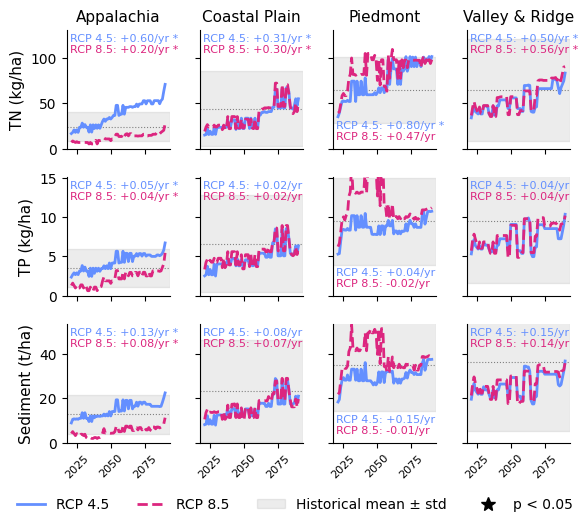

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pymannkendall as mk

df = pd.read_csv('path/to/all_annual_results.csv')

def sig_stars(p):
    if p < 0.05:  return '*'
    return ''

# Baseline only, pooled across crops
base = df[df['bmp'] == 'base'].groupby(['scenario', 'region', 'year'])[['TN', 'TP', 'MUSL']].mean().reset_index()

# Decadal smoothing (11-year rolling median)
def smooth(df, group_cols):
    df = df.sort_values(group_cols + ['year']).copy()
    for m in ['TN', 'TP', 'MUSL']:
        df[m + '_smooth'] = df.groupby(group_cols)[m].transform(
            lambda s: s.rolling(11, center=True, min_periods=6).median())
    return df

base = smooth(base, ['scenario', 'region'])

hist_base = (base[base['scenario'] == 'reference period']
             .groupby(['region', 'year'])[['TN', 'TP', 'MUSL']].mean().reset_index())
fut_base  = base[base['scenario'].isin(['RCP 45', 'RCP 85'])]

regions      = ['a', 'cp', 'p', 'vr']
region_names = {'a': 'Appalachia', 'cp': 'Coastal Plain', 'p': 'Piedmont', 'vr': 'Valley & Ridge'}
metrics      = ['TN', 'TP', 'MUSL']
metric_labels = {'TN': 'TN (kg/ha)', 'TP': 'TP (kg/ha)', 'MUSL': 'Sediment (t/ha)'}
colors  = {'RCP 45': '#648FFF', 'RCP 85': '#DC267F'}
labels  = {'RCP 45': 'RCP 4.5',  'RCP 85': 'RCP 8.5'}
styles  = {'RCP 45': '-',         'RCP 85': '--'}

fig, axes = plt.subplots(3, 4, figsize=(6, 5), sharex='col', sharey='row')

for j, reg in enumerate(regions):
    for i, m in enumerate(metrics):
        ax = axes[i, j]

        # Historical reference band: mean ± std
        h_vals = hist_base[hist_base['region'] == reg][m]
        h_mean, h_std = h_vals.mean(), h_vals.std()
        ax.axhspan(h_mean - h_std, h_mean + h_std, color='gray', alpha=0.15, zorder=0)
        ax.axhline(h_mean, color='gray', linestyle=':', linewidth=0.8, zorder=1)

        # Smoothed future lines + MK/Theil-Sen annotations
        slope_text = []
        for sc in ['RCP 45', 'RCP 85']:
            sub = fut_base[(fut_base['scenario'] == sc) & (fut_base['region'] == reg)].sort_values('year')
            ax.plot(sub['year'], sub[m + '_smooth'],
                    color=colors[sc], linestyle=styles[sc], linewidth=2, label=labels[sc])
            # MK p-value and Theil-Sen slope on annual values
            annual_vals = sub[m].dropna().values
            p     = mk.original_test(annual_vals).p
            slope = stats.theilslopes(annual_vals).slope
            slope_text.append((sc, slope, p))

        # adjust for piedmont
        y_positions = [0.15, 0.06] if reg == 'p' else [0.97, 0.88]
        va_style    = 'bottom' if reg == 'p' else 'top'

        for k, y in enumerate(y_positions):
            idx, slope, p_val = slope_text[k]
            ax.text(0.03, y, f"{labels[idx]}: {slope:+.2f}/yr {sig_stars(p_val)}",
                    transform=ax.transAxes, color=colors[idx], va=va_style, fontsize=8)

        # Y-axis cap at 99th percentile of smoothed future values
        all_smooth = fut_base[fut_base['region'] == reg][m + '_smooth'].dropna()
        ax.set_ylim(0, np.percentile(all_smooth, 99) * 1.5)

        if i == 0: ax.set_title(region_names[reg], fontsize=11)
        if j == 0: ax.set_ylabel(metric_labels[m], fontsize=11)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        #adjust tickmarks
        ax.tick_params(axis='x', labelrotation=45, labelsize=8)

handles, lbls = axes[0, 0].get_legend_handles_labels()

# add historical period
hist_patch = plt.matplotlib.patches.Patch(color='gray', alpha=0.15, label='Historical mean ± std')
handles.append(hist_patch)
lbls.append('Historical mean ± std')

# add star
star_label = plt.Line2D([0], [0], marker='*', linestyle='None', color='black', markersize=10, label='p < 0.05')
handles.append(star_label)
lbls.append('p < 0.05')



fig.legend(handles, lbls, loc='center', ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.02), fontsize=10)

plt.tight_layout()
plt.savefig(output_root + 'annual_loads_clean.png',
            dpi=300, bbox_inches='tight')
plt.show()

### Long-term performance

#### All BMPs

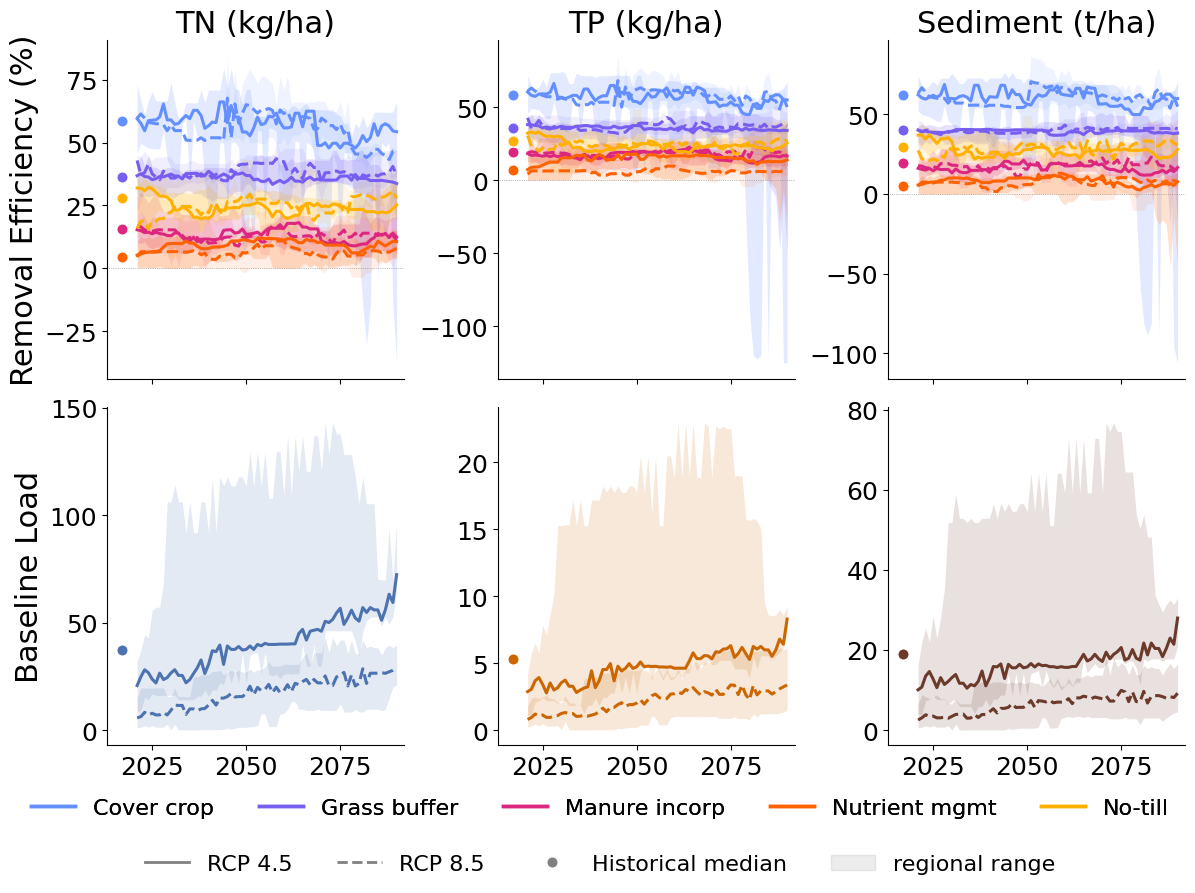

In [ ]:
# configuration
DATA_CSV  = '/path/to/all_annual_results.csv'
OUT_DIR   = 'path/to/output/dir'

REGIONS   = ['a', 'cp', 'p', 'vr']
BMPS      = ['cc', 'gb', 'ma', 'nm', 'nt']
METRICS   = ['RE_TN', 'RE_TP', 'RE_MUSL']
SCENARIOS = ['RCP 45', 'RCP 85']

# load and filter
df = pd.read_csv(DATA_CSV)
df = df.drop(columns=[c for c in df.columns if c.startswith('Unnamed')], errors='ignore')

hist = df[df['scenario'] == 'reference period'].copy()
fut  = df[df['scenario'] != 'reference period'].copy()

def filter_failures(df):
    df = df.copy()
    df['crop_fail'] = (df['YLDG'] + df['YLDF'] == 0)
    base_fail = (df[df['bmp'] == 'base']
                 [['scenario', 'crop', 'region', 'year', 'crop_fail']]
                 .rename(columns={'crop_fail': 'base_fail'}))
    df = df.merge(base_fail, on=['scenario', 'crop', 'region', 'year'], how='left')
    return df[(~df['crop_fail']) & (~df['base_fail'])]

fut_f  = filter_failures(fut);  fut_f  = fut_f[~fut_f['bmp'].isin(['base', 'ma-base'])]
hist_f = filter_failures(hist); hist_f = hist_f[~hist_f['bmp'].isin(['base', 'ma-base'])]

agg_fut  = fut_f.groupby(['scenario', 'region', 'bmp', 'year'])[METRICS].median().reset_index()
agg_hist = hist_f.groupby(['region', 'bmp', 'year'])[METRICS].median().reset_index()

# fig configuration
STABLE_BMPS  = ['cc','gb', 'ma', 'nm', 'nt']
BMP_COLORS   = {'cc':'#648FFF','gb':'#785EF0','ma':'#DC267F','nm':'#FE6100','nt':'#FFB000'}
BMP_LABELS   = {'cc':'Cover crop','gb':'Grass buffer','ma':'Manure incorp','nm':'Nutrient mgmt','nt':'No-till'}
METRIC_LABELS= {'RE_TN':'TN (kg/ha)','RE_TP':'TP (kg/ha)','RE_MUSL':'Sediment (t/ha)'}
LOAD_METRICS = ['TN', 'TP', 'MUSL']
LOAD_LABELS  = {'TN':'TN (kg/ha)', 'TP':'TP (kg/ha)', 'MUSL':'Sediment (t/ha)'}
POLLUTANT_COLORS = {'TN': '#4C72B0', 'TP': '#CC6600', 'MUSL': '#6B3A2A'}  # blue, orange, brown

def smooth_11yr(df, group_cols, metrics):
    df = df.sort_values(group_cols + ['year']).copy()
    for m in metrics:
        df[m + '_smooth'] = df.groupby(group_cols)[m].transform(
            lambda s: s.rolling(11, center=True, min_periods=6).median())
    return df

# smooth RE metrics for top row (pooled across regions by scenario/bmp/year)
agg_fut_s = smooth_11yr(agg_fut.copy(), ['scenario', 'region', 'bmp'], METRICS)

# Baseline loads: filter to base BMP, pool across regions by scenario/year
base_fut  = df[(df['scenario'] != 'reference period') & (df['bmp'] == 'base')].copy()
base_hist = df[(df['scenario'] == 'reference period') & (df['bmp'] == 'base')].copy()

# Aggregate to region/year first, then smooth across that
base_fut_agg  = base_fut.groupby(['scenario', 'region', 'year'])[LOAD_METRICS].median().reset_index()
base_hist_agg = base_hist.groupby(['region', 'year'])[LOAD_METRICS].median().reset_index()
base_fut_agg  = smooth_11yr(base_fut_agg,  ['scenario', 'region'], LOAD_METRICS)
base_hist_agg = smooth_11yr(base_hist_agg, ['region'],             LOAD_METRICS)

def pool_regions(df, bmp, metric_smooth, scenario):
    """Pool RE across regions: median + IQR across regions at each year."""
    sub = df[(df['bmp'] == bmp) & (df['scenario'] == scenario)]
    g   = sub.groupby('year')[metric_smooth]
    return pd.DataFrame({
        'year':   sorted(sub['year'].unique()),
        'median': g.median().values,
        'min':    g.min().values,
        'max':    g.max().values,
    })

def pool_baseline(df, scenario, metric_smooth):
    """Pool baseline loads across regions: median + IQR across regions at each year."""
    sub = df[df['scenario'] == scenario]
    g   = sub.groupby('year')[metric_smooth]
    return pd.DataFrame({
        'year':   sorted(sub['year'].unique()),
        'median': g.median().values,
        'min':    g.min().values,
        'max':    g.max().values,
    })

# plot
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True)

# top row: REs
for i, m in enumerate(METRICS):
    ax = axes[0, i]
    ms = m + '_smooth'
    ax.axhline(0, color='gray', linewidth=0.5, linestyle=':', zorder=0)

    for bmp in STABLE_BMPS:
        p45 = pool_regions(agg_fut_s, bmp, ms, 'RCP 45')
        p85 = pool_regions(agg_fut_s, bmp, ms, 'RCP 85')

        col    = BMP_COLORS[bmp]

        for seg, ls, alpha_fill in [(p45, '-', 0.18), (p85, '--', 0.10)]:
            ax.fill_between(seg['year'], seg['min'], seg['max'], color=col, alpha=alpha_fill, linewidth=0, zorder=2)
            ax.plot(seg['year'], seg['median'], color=col, linestyle=ls, linewidth=2.2, zorder=3)

        # Historical median dot
        h_vals = agg_hist[agg_hist['bmp'] == bmp][m].dropna().values
        if len(h_vals):
            ax.plot(2017, np.median(h_vals), marker='o', markersize=8, color=col,
                    markeredgecolor='white', markeredgewidth=0.8, zorder=4)

    ax.set_title(METRIC_LABELS[m], fontsize=22)
    if i == 0: ax.set_ylabel('Removal Efficiency (%)', fontsize=22)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(2013, 2092)
    ax.tick_params(labelsize=18)


# bottom row: baseline loads
for i, m in enumerate(LOAD_METRICS):
    ax = axes[1, i]
    ms = m + '_smooth'
    col = POLLUTANT_COLORS[m]

    for sc, ls in [('RCP 45', '-'), ('RCP 85', '--')]:
        p = pool_baseline(base_fut_agg, sc, ms)

        # shade range
        ax.fill_between(p['year'], p['min'], p['max'],
                        color=col, alpha=0.15, linewidth=0, zorder=2)
        ax.plot(p['year'], p['median'],
                color=col, linestyle=ls, linewidth=2.2, zorder=3)

    # Historical median dot
    h_vals = base_hist_agg.groupby('year')[m].median()
    ax.plot(2017, h_vals.median(), marker='o', markersize=8, color=col,
            markeredgecolor='white', markeredgewidth=0.8, zorder=4)

    if i == 0: ax.set_ylabel('Baseline Load', fontsize=22)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=18)

# legend
handles_bmp = [plt.Line2D([0],[0], color=BMP_COLORS[b], linewidth=2.5, label=BMP_LABELS[b]) for b in STABLE_BMPS]
handles_rcp = [plt.Line2D([0],[0], color='gray', linestyle='-',  linewidth=2, label='RCP 4.5'),
               plt.Line2D([0],[0], color='gray', linestyle='--', linewidth=2, label='RCP 8.5'),
               plt.Line2D([0],[0], marker='o', markersize=8, linestyle='', color='gray',markeredgecolor='white', markeredgewidth=0.8, label='Historical median'),
               plt.matplotlib.patches.Patch(color='gray', alpha=0.15, label='regional range')]
leg1 = fig.legend(handles=handles_bmp, loc='upper center', ncol=5, frameon=False, bbox_to_anchor=(0.5, 0.02), fontsize=16)
fig.add_artist(leg1)
fig.legend(handles=handles_rcp, loc='upper center', ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.05), fontsize=16)

plt.tight_layout()
plt.savefig(OUT_DIR + 'figure_all_annual_BMPs_pooled.png', dpi=300, bbox_inches='tight')
plt.show()

#### CC only

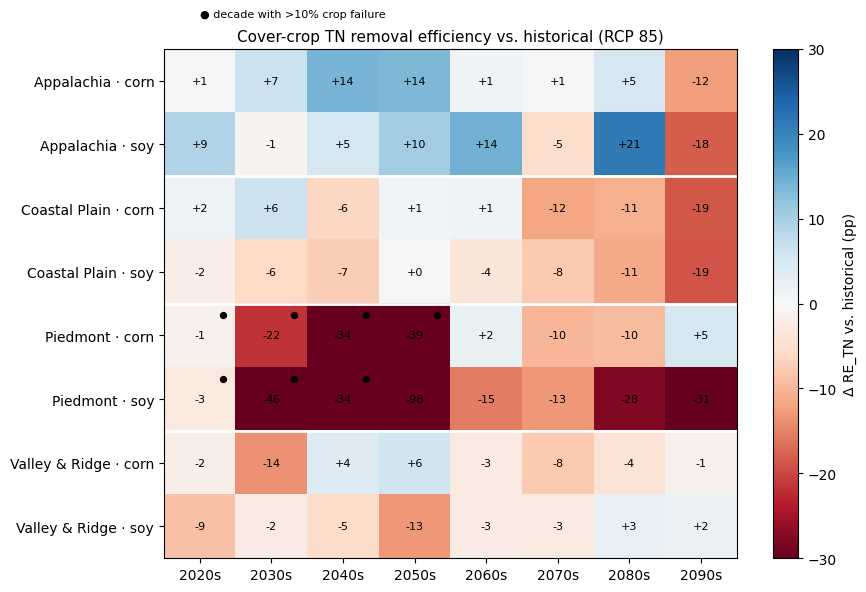

In [ ]:
# CC heatmap
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# configuration
CSV       = "/path/to/all_annual_results.csv"
SCENARIO  = "RCP 85"                        # "RCP 45" or "RCP 85"
FAIL_FLAG = 0.10                            # mark a decade if >10% of its yrs are crop-failure
VLIM      = 30                              # color scale: +/- this many percentage points
OUTFILE   = "output/path/cc_annual_heatmap_85.png"
REGIONS   = ["a", "cp", "p", "vr"]          # row order
RLABEL    = {"a":"Appalachia","cp":"Coastal Plain","p":"Piedmont","vr":"Valley & Ridge"}
DECADES   = [2020,2030,2040,2050,2060,2070,2080,2090]

df   = pd.read_csv(CSV)
base = df[df.bmp=="base"][["scenario","crop","region","year","YLDG","YLDF"]].rename(
       columns={"YLDG":"bG","YLDF":"bF"})
cc   = df[df.bmp=="cc"].merge(base, on=["scenario","crop","region","year"], how="left")
cc["fail"] = ((cc.YLDG+cc.YLDF)==0) | ((cc.bG+cc.bF)==0)
ccf  = cc[(~cc.fail) & np.isfinite(cc.RE_TN)]          # filtered for RE medians

hist = ccf[ccf.scenario=="reference period"].groupby(["region","crop"]).RE_TN.median()
fut  = ccf[ccf.scenario==SCENARIO].copy(); fut["dec"]=(fut.year//10)*10

rows, delta, flag = [], [], []
for reg in REGIONS:
    for crop in ["corn","soy"]:
        rows.append(f"{RLABEL[reg]} · {crop}")
        h = hist.get((reg,crop), np.nan)
        drow, frow = [], []
        for dec in DECADES:
            sub  = fut[(fut.region==reg)&(fut.crop==crop)&(fut.dec==dec)]
            allr = cc[(cc.scenario==SCENARIO)&(cc.region==reg)&(cc.crop==crop)&((cc.year//10*10)==dec)]
            drow.append(sub.RE_TN.median()-h if len(sub) else np.nan)
            frow.append(allr.fail.mean()>FAIL_FLAG if len(allr) else False)
        delta.append(drow); flag.append(frow)
delta = np.array(delta, float); flag = np.array(flag, bool)

# plot
fig, ax = plt.subplots(figsize=(9, 6))
norm = TwoSlopeNorm(vmin=-VLIM, vcenter=0, vmax=VLIM)
im = ax.imshow(delta, cmap="RdBu", norm=norm, aspect="auto")

for i in range(delta.shape[0]):
    for j in range(delta.shape[1]):
        if np.isfinite(delta[i,j]):
            ax.text(j, i, f"{delta[i,j]:+.0f}", ha="center", va="center", fontsize=8)
        if flag[i,j]:                                   # failure-contaminated decade
            ax.scatter(j+0.32, i-0.32, s=18, color="black", zorder=3)

ax.set_xticks(range(len(DECADES))); ax.set_xticklabels([f"{d}s" for d in DECADES])
ax.set_yticks(range(len(rows)));   ax.set_yticklabels(rows)
for k in range(2, len(rows), 2):                        # separate regions
    ax.axhline(k-0.5, color="white", lw=2)
ax.set_title(f"Cover-crop TN removal efficiency vs. historical ({SCENARIO})", fontsize=11)
cbar = fig.colorbar(im, ax=ax, label="Δ RE_TN vs. historical (pp)")
ax.text(0.0, -1.0, "● decade with >10% crop failure", fontsize=8, color="black", transform=ax.transData)
fig.tight_layout()

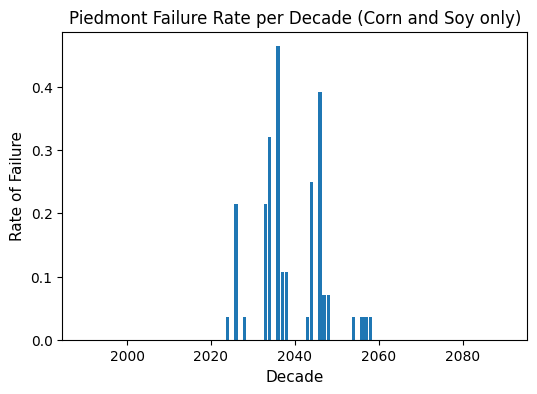

In [ ]:
# Piedmont failures
CSV = "path/to/all_annual_results.csv"
df = pd.read_csv(CSV)
# bar chart of how many failures occurred in each decade
piedmont = df[df['region']=='p']
# look at corn and soy only (only crops with CC)
piedmont = piedmont[piedmont['crop'].isin(['corn','soy'])]
piedmont['crop_fail'] = (piedmont['YLDG'] + piedmont['YLDF'] == 0)
piedmont_fail = piedmont.groupby('year')['crop_fail'].mean()
# piedmont_fail = piedmont_fail.groupby(piedmont_fail.index // 10 * 10).mean()

# plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(piedmont_fail.index, piedmont_fail.values)
ax.set_xlabel('Decade', fontsize=11)
ax.set_ylabel('Rate of Failure', fontsize=11)
ax.set_title('Piedmont Failure Rate per Decade (Corn and Soy only)', fontsize=12)
fig.savefig(output_root + 'piedmont_failure_rate.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/x6/4q6mkk_n2wgbv7vyghrnt0m80000gn/T/ipykernel_37942/886708343.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


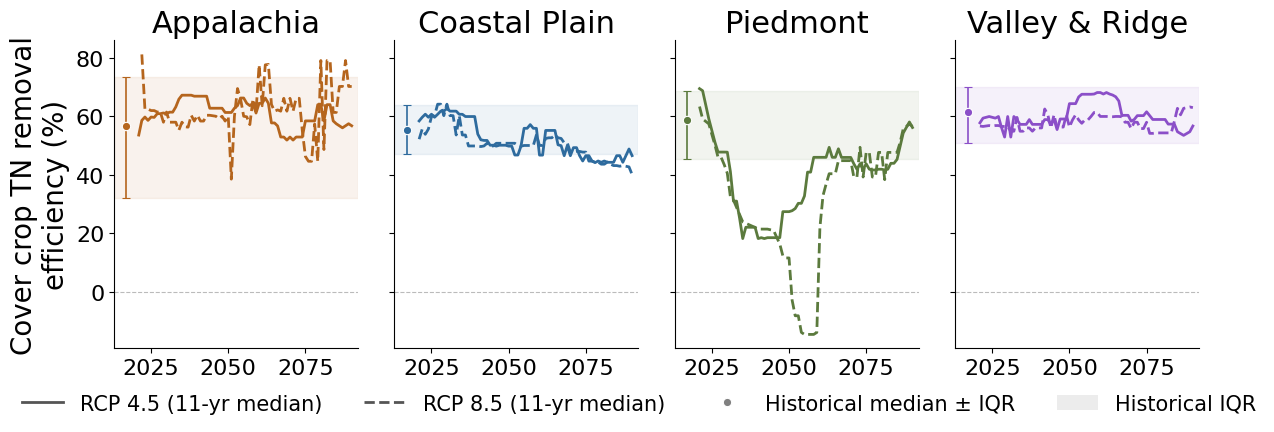

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches  # Fixed: Needed for matplotlib.patches.Patch
from matplotlib.lines import Line2D  # Fixed: Needed for Line2D

REG_COL      = {'a': '#B5651D', 'cp': '#2E6B9E', 'p': '#5B7A3D', 'vr': '#8B4FC8'}
REGION_NAMES = {'a': 'Appalachia', 'cp': 'Coastal Plain', 'p': 'Piedmont', 'vr': 'Valley & Ridge'}
REGIONS      = ['a', 'cp', 'p', 'vr']

df = pd.read_csv('/path/to/all_annual_results.csv')
hist = df[df['scenario'] == 'reference period'].copy()
fut  = df[df['scenario'] != 'reference period'].copy()

# Filter crop failures
def filter_failures(df):
    df = df.copy()
    df['crop_fail'] = (df['YLDG'] + df['YLDF'] == 0)
    base_fail = df[df['bmp'] == 'base'][['scenario', 'crop', 'region', 'year', 'crop_fail']].rename(columns={'crop_fail': 'base_fail'})
    df = df.merge(base_fail, on=['scenario', 'crop', 'region', 'year'], how='left')
    return df[(~df['crop_fail']) & (~df['base_fail'])]

fut_f = filter_failures(fut)
fut_f = fut_f[~fut_f['bmp'].isin(['base', 'ma-base'])]
fut_f['RE_TN'] = fut_f['RE_TN'].replace([np.inf, -np.inf], np.nan)

# Aggregate TN for cc only
cc_agg = (fut_f[fut_f['bmp'] == 'cc']
          .groupby(['scenario', 'region', 'year'])['RE_TN'].median().reset_index())
cc_agg = cc_agg.sort_values(['scenario', 'region', 'year'])
cc_agg['RE_smooth'] = cc_agg.groupby(['scenario', 'region'])['RE_TN'].transform(
    lambda s: s.rolling(11, center=True, min_periods=6).median())

hist_cc   = hist[hist['bmp'] == 'cc'][['region', 'year', 'RE_TN']].copy()
hist_cc['RE_TN'] = hist_cc['RE_TN'].replace([np.inf, -np.inf], np.nan)
hist_med  = hist_cc.groupby('region')['RE_TN'].median()
hist_q25  = hist_cc.groupby('region')['RE_TN'].quantile(0.25)
hist_q75  = hist_cc.groupby('region')['RE_TN'].quantile(0.75)

# Plot
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharex=True, sharey=True,
                         gridspec_kw={'wspace': 0.15})  # Changed hspace to wspace since it's 1 row, 4 cols
fig.patch.set_facecolor('white')

# iterate across every region and its respective subplot axis
for i, reg in enumerate(REGIONS):
    ax = axes[i]  # Track the current subplot
    col = REG_COL[reg]
    
    # background references
    ax.axhline(0, color='#bbbbbb', lw=0.8, ls='--', zorder=0)
    ax.axhspan(hist_q25[reg], hist_q75[reg], color=col, alpha=0.08, zorder=0)
    
    # Projections loop
    for sc, ls in [('RCP 45', '-'), ('RCP 85', '--')]:
        sub = cc_agg[(cc_agg['region'] == reg) & (cc_agg['scenario'] == sc)].sort_values('year')
        ax.plot(sub['year'], sub['RE_smooth'], color=col, linestyle=ls, linewidth=2.0, zorder=3)
    
    # Historical marker
    ax.errorbar(2017, hist_med[reg],
                yerr=[[hist_med[reg] - hist_q25[reg]], [hist_q75[reg] - hist_med[reg]]],
                fmt='o', color=col, markersize=6, capsize=3,
                elinewidth=1.2, zorder=5, markeredgecolor='white', markeredgewidth=0.8)
    
    ax.set_title(REGION_NAMES[reg], fontsize=22, color='black')
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(2013, 2092)
    ax.tick_params(labelsize=16)
    
    if i == 0:
        ax.set_ylabel('Cover crop TN removal\nefficiency (%)', fontsize=20)

# items
handles = [
    Line2D([0], [0], color='#555555', ls='-',  lw=2.0, label='RCP 4.5 (11-yr median)'),
    Line2D([0], [0], color='#555555', ls='--', lw=2.0, label='RCP 8.5 (11-yr median)'),
    Line2D([0], [0], color='gray', marker='o', ms=6, lw=0,
           markeredgecolor='white', markeredgewidth=0.8, label='Historical median ± IQR'),
    matplotlib.patches.Patch(facecolor='gray', alpha=0.15, label='Historical IQR'),
]

# legend
fig.legend(handles=handles, loc='lower center', ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.1), fontsize=15)

plt.tight_layout()  
plt.show()
plt.savefig(output_root + 'cc_tn_removal_by_region.png', dpi=300, bbox_inches='tight')


### Operational Phase

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import theilslopes
import pymannkendall as mk
import warnings
warnings.filterwarnings("ignore")

# configuration
INFILE   = "/path/to/phase_re_dataset.csv"
OUTBASE  = "/outpath/to/fig_phase_trends_two_panel"
METRIC   = "re_TN"
PERIOD   = (2021, 2090)            # RCP window for both panels
ROWS     = ["nm", "cc", "gb", "ma", "nt"]      # mechanism-grouped row order
PHASES   = ["preplant", "midseason", "postharvest"]
GROUP_SEP = [0.5, 1.5]            # h-lines after NM (source) and CC (hybrid)
LVL_SCALE = (-15, 0, 55)         # panel (a) colorbar: vmin, vcenter, vmax 
SLP_SCALE = (-2.5, 0, 2.5)       # panel (b) colorbar
KEYS = ["scenario","region","crop","bmp","phase_year","phase"]
LBL  = {"nm":"Nutrient\nManagement","cc":"Cover Crops","gb":"Grass Buffer","ma":"Manure\nIncorporation","nt":"No-Till"}
MECH = {"nm":"Source\nReduction","cc":"Hybrid","gb":"Transport","ma":"Transport","nt":"Transport"}
PLAB = ["Pre-\nPlant","Mid-\nSeason","Post-\nHarvest"]

df = pd.read_csv(INFILE)
dup = df.duplicated(subset=KEYS, keep=False)
df  = df[~(dup & (df.bmp_crop_failure == 1))].drop_duplicates(subset=KEYS)
df  = df[(df.baseline_crop_failure == 0) & (df.bmp_crop_failure == 0)]
d   = df[df.scenario.isin(["RCP45","RCP85"]) & df.phase_year.between(*PERIOD)]

LVL = np.full((5,3), np.nan); SLP = np.full((5,3), np.nan); PV = np.full((5,3), np.nan)
for i, b in enumerate(ROWS):
    for j, ph in enumerate(PHASES):
        s = d[(d.bmp == b) & (d.phase == ph)]
        LVL[i,j] = s[METRIC].median()
        ser = s.groupby("phase_year")[METRIC].median().sort_index()   
        SLP[i,j] = theilslopes(ser.values, ser.index.values)[0] * 10
        PV[i,j]  = mk.original_test(ser.values).p

# 1. Update Global Parameters (scaled beautifully for a 6.5 inch width)
plt.rcParams.update({
    "font.size": 10, 
    "axes.linewidth": 0.8,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5
})

# Adjusted vertical padding to make room for colorbar text if needed
fig, (axa, axb) = plt.subplots(1, 2, figsize=(6.5, 4.0), gridspec_kw={"wspace": 0.22})

def draw(ax, M, scale, fmt, sig=None, title=""):
    norm = TwoSlopeNorm(vmin=scale[0], vcenter=scale[1], vmax=scale[2])
    im = ax.imshow(M, cmap="RdBu", norm=norm, aspect="auto")
    
    for i in range(5):
        for j in range(3):
            star = "*" if (sig is not None and sig[i,j] < 0.05) else ""
            
            # Smart text color thresholding: use light text on deeply saturated tiles
            # Left panel max is 55, right panel max is 2.5. 
            if sig is None: # Panel A
                dark = M[i,j] > 35 or M[i,j] < -10
            else: # Panel B
                dark = abs(M[i,j]) > 1.6
                
            ax.text(j, i, fmt.format(M[i,j]) + star, ha="center", va="center",
                    fontsize=11, fontweight="bold" if star else ("bold" if M[i,j] < 0 else "normal"),
                    color="white" if dark else "#111")
                    
    # Scaled titles and labels down to fit without clipping
    ax.set_title(title, fontsize=10.5, fontweight='normal', pad=8, loc="left")
    ax.set_xticks(range(3))
    ax.set_xticklabels(PLAB, ha="center") # Slight rotation prevents collision with colorbar
    
    ax.set_xticks(np.arange(-.5,3,1), minor=True)
    ax.set_yticks(np.arange(-.5,5,1), minor=True)
    ax.grid(which="minor", color="white", lw=1.5)
    ax.tick_params(which="both", length=0)
    
    for y in GROUP_SEP: 
        ax.axhline(y, color="#555555", lw=1.0, ls="-")
    return im

# Draw panels
ima = draw(axa, LVL, LVL_SCALE, "{:+.0f}", None, f"$\\bf{{A}}.$ Phase-Level TN Removal (%)")
imb = draw(axb, SLP, SLP_SCALE, "{:+.1f}", PV, f"$\\bf{{B}}.$ Climate Trend (pp/decade)")

axa.set_yticks(range(5))
axa.set_yticklabels([LBL[b] for b in ROWS], fontsize=9.5)
axb.set_yticks(range(5))
axb.set_yticklabels([])

# 2. Optimized and uniformly padded colorbars
cbar_a = fig.colorbar(ima, ax=axa, fraction=0.046, pad=0.15, extend="neither", orientation='horizontal')
cbar_a.set_label("Median TN Removal (%)", fontsize=9)
cbar_a.ax.tick_params(labelsize=8)

cbar_b = fig.colorbar(imb, ax=axb, fraction=0.046, pad=0.15, extend="neither", orientation='horizontal')
cbar_b.set_label("Theil–Sen Slope", fontsize=9)
cbar_b.ax.tick_params(labelsize=8)


fig.tight_layout()
plt.savefig(f"{OUTBASE}.png", dpi=300, bbox_inches="tight"); plt.close()
plt.show()

### Storm Analysis

#### Loads & storm size

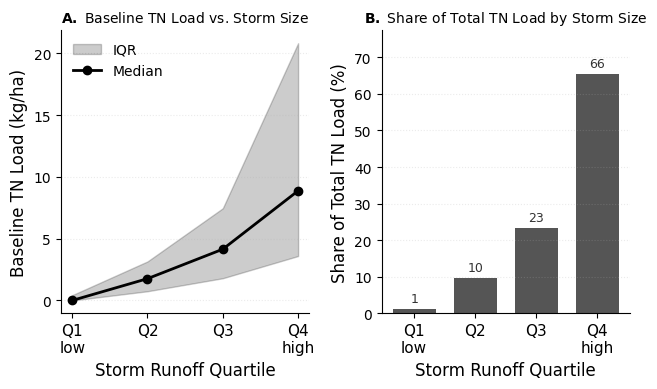

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# configuration
CSV_PATH = r"path/to/storm_analysis_dataset.csv"
BMP_ORDER = ["gb", "nt", "ma", "nm", "cc"]
BMP_NAME = {"gb": "Grass Buffer","nt": "No-till","ma": "Manure Incorp.","nm": "Nutrient Mgmt.","cc": "Cover Crop",}
BMP_COL = {"cc": "#648FFF","gb": "#785EF0","ma": "#DC267F","nm": "#FE6100","nt": "#FFB000",}
METRIC = "TN"
Q_LABELS = ["Q1\nlow", "Q2", "Q3", "Q4\nhigh"]
SCEN = ["historical", "RCP45", "RCP85"]
SCEN_LABELS = ["Historical", "RCP 4.5", "RCP 8.5"]

df = pd.read_csv(CSV_PATH)

# filter zero runoff events and crop failures (baseline & BMP)
d = df[
    (df.baseline_crop_failure == 0)
    & (df.bmp_crop_failure == 0)
    & (df.event_runoff_Q > 0)
].copy()
d["Qq"] = pd.qcut(d.event_runoff_Q, 4, labels=Q_LABELS)

def boot_med_ci(v, n=2000):
    """Bootstrap 95% CI of the median (RE is a median, not a proportion)."""
    v = v.dropna().values
    if len(v) < 10:
        return np.nan, np.nan, np.nan
    m = np.median(np.random.choice(v, (n, len(v)), replace=True), axis=1)
    return np.median(v), np.percentile(m, 2.5), np.percentile(m, 97.5)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(6.5, 4))
plt.subplots_adjust(bottom=0.15)

# Panel 1: baseline load increases with storm size (median + IQR)
q_stats = (
    d.groupby("Qq", observed=True)[f"baseline_{METRIC}"]
    .quantile([0.25, 0.5, 0.75])
    .unstack()
)
ax0.fill_between(
    range(4), q_stats[0.25], q_stats[0.75], alpha=0.2, color="black", label="IQR"
)
ax0.plot(
    range(4), q_stats[0.50], marker="o", color="black", lw=2, label="Median"
)
ax0.set_ylabel(f"Baseline {METRIC} Load (kg/ha)", fontsize=12)
ax0.set_xticks(range(4))
ax0.set_xticklabels(Q_LABELS, fontsize=11)
ax0.set_xlabel("Storm Runoff Quartile", fontsize=12)
ax0.legend(loc="upper left", frameon=False, fontsize=10)
ax0.set_title(f"$\\bf{{A.}}$ Baseline {METRIC} Load vs. Storm Size", fontsize=10)

# Panel 2: load is concentrated in the largest events
# dedupe to one row per storm then share by quartile
stm = d.drop_duplicates(["scenario", "region", "crop", "start"]).copy()
stm["Qq"] = pd.qcut(stm.event_runoff_Q, 4, labels=Q_LABELS)
share = stm.groupby("Qq", observed=True)[f"baseline_{METRIC}"].sum()
share = share / share.sum() * 100

ax1.bar(range(4), share.values, color="#555555", width=0.7)
for i, v in enumerate(share.values):
    ax1.text(i, v + 1, f"{v:.0f}", ha="center", va="bottom", fontsize=9, color="#333")
ax1.set_ylabel(f"Share of Total {METRIC} Load (%)", fontsize=12)
ax1.set_xticks(range(4))
ax1.set_xticklabels(Q_LABELS, fontsize=11)
ax1.set_xlabel("Storm Runoff Quartile", fontsize=12)
ax1.set_ylim(0, max(share.values) * 1.18)
ax1.set_title(f"$\\bf{{B.}}$ Share of Total {METRIC} Load by Storm Size", fontsize=10)

for ax in [ax0, ax1]:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, ls=":")


plt.tight_layout()
plt.savefig(output_root + "storm-TN-load.png", dpi=300, bbox_inches="tight")
plt.show()

#### BMP robustness by mechanism

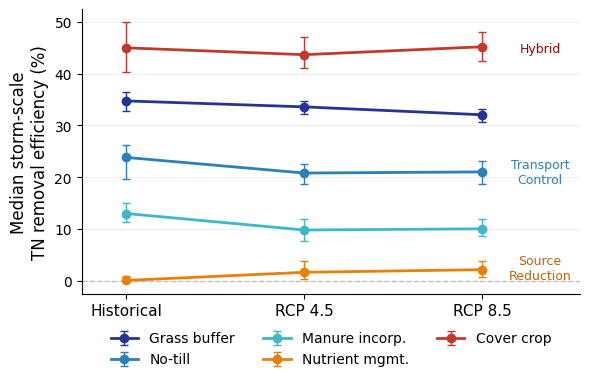

saved /Users/mayastruzak/Library/CloudStorage/Box-Box/cbw-ag-modeling-box/results/plots/final-plots/report_v1/main text/storm_RE_robustness_by_scenario.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# configuration
CSV     = "path/to/storm_analysis_dataset.csv"
OUT_PNG = "outpath/to/storm_RE_robustness_by_scenario.png"
RE_COL  = "re_TN"
N_BOOT  = 2000          # bootstrap resamples for the median CI

SCEN       = ["historical", "RCP45", "RCP85"]
SCEN_LABEL = ["Historical", "RCP 4.5", "RCP 8.5"]
BMP_ORDER  = ["gb", "nt", "ma", "nm", "cc"]
COLOR = {"gb": "#253494", "nt": "#2c7fb8", "ma": "#41b6c4",   # transport (cool)
         "nm": "#e6810a",                                      # source (orange)
         "cc": "#c0392b"}                                      # hybrid (red)
LABEL = {"gb": "Grass buffer", "nt": "No-till", "ma": "Manure incorp.",
         "nm": "Nutrient mgmt.", "cc": "Cover crop"}

# load
df = pd.read_csv(CSV)
w = df[df["baseline_TN"] > 0].copy()        # RE defined only where load is generated

def boot_median_ci(x, n=N_BOOT):
    x = x.dropna().values
    if len(x) < 10:
        return np.nan, np.nan, np.nan
    meds = np.median(np.random.choice(x, (n, len(x)), replace=True), axis=1)
    return np.median(x), np.percentile(meds, 2.5), np.percentile(meds, 97.5)

# plot
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(3)

ax.axhline(0, color="#888", alpha=0.5,lw=1, ls="--", zorder=1)

for bmp in BMP_ORDER:
    meds, los, his = [], [], []
    for s in SCEN:
        m, lo, hi = boot_median_ci(w[(w.bmp == bmp) & (w.scenario == s)][RE_COL])
        meds.append(m); los.append(m - lo); his.append(hi - m)
    ax.errorbar(x, meds, yerr=[los, his], color=COLOR[bmp], lw=2.0, marker="o",
                ms=6, capsize=3, capthick=1, elinewidth=1, zorder=3,
                label=f"{LABEL[bmp]}")

ax.set_xticks(x); ax.set_xticklabels(SCEN_LABEL, fontsize=11)
ax.set_ylabel("Median storm-scale\nTN removal efficiency (%)", fontsize=12)
# ax.set_xlabel("Climate scenario", fontsize=12)
ax.set_xlim(-0.25, 2.55)

# add annotations regions for mechanisms
ax.annotate("Transport\nControl", xy=(0.92, 0.39), xycoords="axes fraction", fontsize=9, ha="center", color="#2A82C1")
ax.annotate("Source\nReduction", xy=(0.92, 0.05), xycoords="axes fraction", fontsize=9, ha="center", color="#BF6600")
ax.annotate("Hybrid", xy=(0.92, 0.85), xycoords="axes fraction", fontsize=9, ha="center", color="#A10000")

ax.legend(frameon=False, fontsize=10, loc="lower center", bbox_to_anchor=(0.5, -0.3), ncol=3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25, lw=0.6)
fig.tight_layout()
fig.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.show()
print("saved", OUT_PNG)

#### Cover Crop mechanism

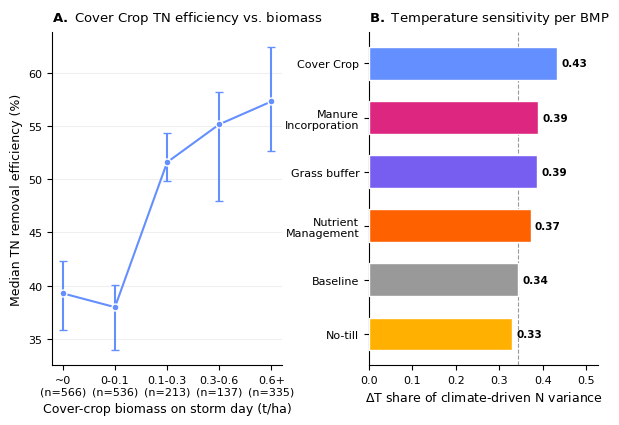


Panel A:
     bin    median        lo        hi   n
     ~0 39.280063 35.803458 42.356064 566
  0-0.1 37.985771 33.966540 40.036773 536
0.1-0.3 51.585911 49.854227 54.314997 213
0.3-0.6 55.145262 47.957542 58.201449 137
   0.6+ 57.290144 52.662937 62.379408 335

Panel B (dt share):
 bmp
nt      0.329
base    0.343
nm      0.372
gb      0.387
ma      0.389
cc      0.433


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Config
STORM_CSV = r"/path/to/storm_analysis_dataset.csv"
SOBOL_CSV = r"/path//to/all_sobol_climate.csv"
OUT_FIG   = r"outpath/to/cc_mechanism_2panel.png"
SEED      = 1
N_BOOT    = 5000
BIOM_BINS = [-.01, .001, .1, .3, .6, 20]
BIOM_LABS = ["~0", "0-0.1", "0.1-0.3", "0.3-0.6", "0.6+"]
PAL = {"cc":"#648FFF","gb":"#785EF0","ma":"#DC267F","nm":"#FE6100","nt":"#FFB000","base":"#999999"}
LAB = {"cc":"Cover Crop","gb":"Grass buffer","ma":"Manure\nIncorporation","nm":"Nutrient\nManagement","nt":"No-till","base":"Baseline"}

rng = np.random.default_rng(SEED)

# Panel A data
cc = pd.read_csv(STORM_CSV)
cc = cc[(cc.bmp=="cc") & (cc.baseline_TN>0) & cc.cover_BIOM.notna() & cc.re_TN.notna()].copy()
cc["bin"] = pd.cut(cc.cover_BIOM, BIOM_BINS, labels=BIOM_LABS)
def boot_med_ci(v, n=N_BOOT):
    v = v.values
    bs = [np.median(v[rng.integers(0, len(v), len(v))]) for _ in range(n)]
    return np.median(v), np.percentile(bs, 2.5), np.percentile(bs, 97.5)
A = pd.DataFrame([(lab, *boot_med_ci(g.re_TN), len(g))
                  for lab, g in cc.groupby("bin", observed=True)],
                 columns=["bin","median","lo","hi","n"])

# Panel B data
sob = pd.read_csv(SOBOL_CSV)
nmet = sob[sob.metric.isin(["YNkg/ha","QNkg/ha"])]
dt = nmet[nmet.parameter=="delta_t"].groupby("bmp").S1.mean()
dp = nmet[nmet.parameter=="delta_p"].groupby("bmp").S1.mean()
share = (dt/(dt+dp)).sort_values()


# 1. Target physical size directly (6.5 x 4.5 inches)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.5, 4.5))
fig.patch.set_facecolor('white')

# Panel A
ax1.errorbar(range(len(A)), A["median"], yerr=[A["median"]-A["lo"], A["hi"]-A["median"]],
             fmt="o-", color=PAL["cc"], ecolor=PAL["cc"], capsize=3, lw=1.5, ms=5, mec="white", mew=1.0)

ax1.set_xticks(range(len(A)))
ax1.set_xticklabels([f"{b}\n(n={n})" for b,n in zip(A.bin, A.n)], fontsize=7.5)

ax1.set_xlabel("Cover-crop biomass on storm day (t/ha)", fontsize=9, labelpad=4)
ax1.set_ylabel("Median TN removal efficiency (%)", fontsize=9, labelpad=4)
ax1.grid(axis="y", color="#e5e5e5", alpha=0.6, zorder=0)
ax1.spines[["top","right"]].set_visible(False)
ax1.tick_params(labelsize=8)

ax1.set_title(r"$\bf{A.}$ Cover Crop TN efficiency vs. biomass", fontsize=9.5, pad=8, loc='left')

# Panel B
colors = [PAL[b] for b in share.index]
bars = ax2.barh([LAB[b] for b in share.index], share.values, color=colors, ec="white", height=0.6, zorder=3)
ax2.axvline(share["base"], color="#999", ls="--", lw=0.8, zorder=0)

for b, v in zip(bars, share.values):
    ax2.text(v + 0.01, b.get_y() + b.get_height()/2, f"{v:.2f}", va="center", ha="left", fontsize=7.5, fontweight='bold')

ax2.set_xlabel(r"$\Delta$T share of climate-driven N variance", fontsize=9, labelpad=4)
ax2.set_title(r"$\bf{B.}$ Temperature sensitivity per BMP", fontsize=9.5, pad=8, loc='left')
ax2.spines[["top","right"]].set_visible(False)
ax2.tick_params(labelsize=8)

ax2.set_xlim(0, max(share.values) * 1.22)

plt.subplots_adjust(left=0.12, right=0.96, bottom=0.14, top=0.88, wspace=0.38)

plt.savefig(OUT_FIG, dpi=300, bbox_inches="tight")
plt.show()

print("\nPanel A:\n", A.to_string(index=False))
print("\nPanel B (dt share):\n", share.round(3).to_string())


### Synthetic Storm

#### Corn mechanism CC vs TC

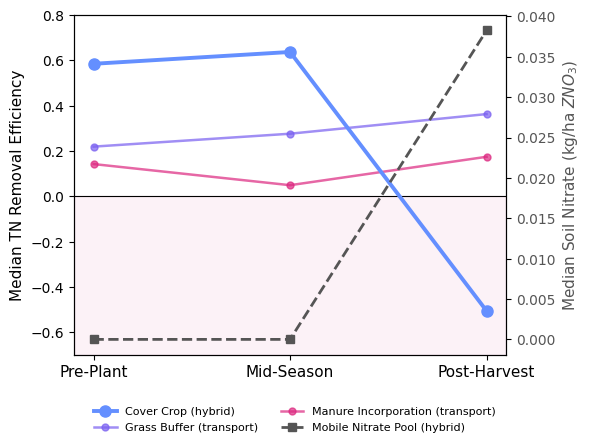

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Load data
corn = pd.read_csv("/path/to/synthetic_corn_results.csv")
corn = corn[corn.undefined == False]

WINS = ["preplant", "midseason", "postharvest"]
WINS_LABELS = ["Pre-Plant", "Mid-Season", "Post-Harvest"]
PAL = {"cc": "#648FFF", "gb": "#785EF0", "ma": "#DC267F"}
LAB = {"cc": "Cover Crop (hybrid)", "gb": "Grass Buffer (transport)", "ma": "Manure Incorporation (transport)"}

r = corn[corn.bmp.isin(['cc', 'gb', 'ma'])]

# plot
fig, ax1 = plt.subplots(figsize=(6, 4))
ax2 = ax1.twinx()  # Create the secondary y-axis

# base style
ax1.axhspan(-0.7, 0, color="#DC267F", alpha=0.06)
ax1.axhline(0, color="k", lw=0.8)

x = np.arange(3)

# plot left y-axis: TN_RE
for b in ['cc', 'gb', 'ma']:
    y = [r[(r.bmp == b) & (r.window == w)].RE_TN.median() for w in WINS]
    em = (b == 'cc')
    ax1.plot(x, y, "-o", color=PAL[b], lw=2.8 if em else 1.8, ms=8 if em else 5,
             alpha=1 if em else 0.7, label=LAB[b], zorder=3 if em else 2)

ax1.set_xticks(x)
ax1.set_xticklabels(WINS_LABELS, fontsize=11)
ax1.set_ylabel("Median TN Removal Efficiency", fontsize=11)
ax1.set_ylim(-0.7, 0.8)

# plot secondary y-axis: soil nitrate (ZNO3)
cc_data = r[r.bmp == 'cc']
y_nitrate = [cc_data[cc_data.window == w].ZNO3.median() for w in WINS]

ax2.plot(x, y_nitrate, "--s", color="#555555", lw=2, ms=6, label="Mobile Nitrate Pool (hybrid)")
ax2.set_ylabel("Median Soil Nitrate (kg/ha $ZNO_3$)", fontsize=11, color="#555555")
ax2.tick_params(axis='y', labelcolor="#555555")

Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2, fontsize=8, 
           loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.12), frameon=False)

fig.tight_layout()
plt.show()
fig.savefig(output_root + "synthetic-corn-mech.png", dpi=300, bbox_inches="tight"); plt.close()


#### all BMPs

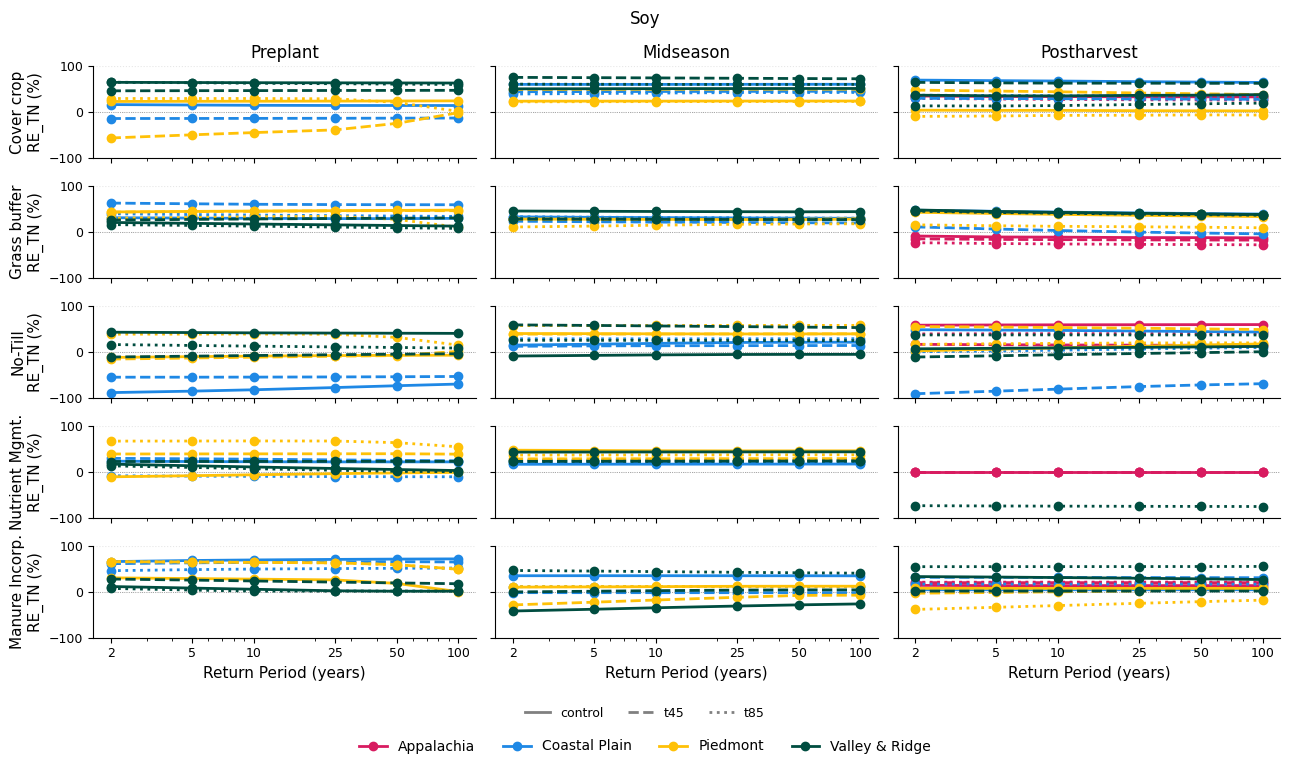

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# configuratuon
SCENARIO = 'all'                          # 'control', 't45', 't85', or 'all'
BMPS     = ['cc','gb','nt','nm','ma']     # display in order
METRIC   = 'RE_TN'                        # 'RE_TN', 'RE_TP', or 'RE_sed' (stored as fractions)
CROP    = 'soy'                         # 'corn' or 'soy'
CSV_PATH = f'/path/to/synthetic_{CROP}_results.csv'

# load
re = pd.read_csv(CSV_PATH)
re = re[re[METRIC].notna()]

region_order  = ['appalachia','coastal_plain','piedmont','valley_ridge']
region_names  = {'appalachia':'Appalachia','coastal_plain':'Coastal Plain',
                 'piedmont':'Piedmont','valley_ridge':'Valley & Ridge'}
region_colors = {'appalachia':'#D81B60','coastal_plain':'#1E88E5',
                 'piedmont':'#FFC107','valley_ridge':'#004D40'}
bmp_labels    = {'cc':'Cover crop','gb':'Grass buffer','ma':'Manure Incorp.',
                 'nm':'Nutrient Mgmt.','nt':'No-Till'}
window_labels = {'preplant':'Preplant','midseason':'Midseason','postharvest':'Postharvest'}
dt_styles     = {'control':'-','t45':'--','t85':':'}
dt_values     = {'control':0.0,'t45':2.03,'t85':2.70}   # scenario label -> numeric dT

scenarios = ['control','t45','t85'] if SCENARIO == 'all' else [SCENARIO]
nrows = len(BMPS)

# plot
fig, axes = plt.subplots(nrows, 3, figsize=(13, max(2.5, 1.4*nrows)),
                         sharex=True, sharey=True, squeeze=False)

for i, bmp in enumerate(BMPS):
    for j, window in enumerate(['preplant','midseason','postharvest']):
        ax = axes[i, j]
        ax.axhline(0, color='gray', linewidth=0.6, linestyle=':', zorder=0)

        for reg in region_order:
            for dt in scenarios:
                sub = re[(re['bmp']==bmp) & (re['window']==window) &
                         (re['region']==reg) & (re['dT']==dt_values[dt])
                         ].sort_values('return_period')
                ax.plot(sub['return_period'], sub[METRIC]*100,     # fraction -> %
                        marker='o', markersize=6, linewidth=2,
                        color=region_colors[reg], linestyle=dt_styles[dt],
                        label=region_names[reg] if (i==0 and j==0 and dt==scenarios[0]) else None)

        ax.set_xscale('log')
        ax.set_xticks([2, 5, 10, 25, 50, 100])
        ax.set_xticklabels([2, 5, 10, 25, 50, 100])

        if i == nrows - 1:
            ax.set_xlabel('Return Period (years)', fontsize=11)
        if j == 0:
            ax.set_ylabel(f'{bmp_labels[bmp]}\n{METRIC} (%)', fontsize=11)
        if i == 0:
            ax.set_title(window_labels[window], fontsize=12)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', alpha=0.3, linestyle=':')
        ax.tick_params(labelsize=9)
        ax.set_ylim(-100, 100)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.1), fontsize=10)
if SCENARIO == 'all':
    dt_handles = [plt.Line2D([0],[0], color='gray', linestyle=dt_styles[d], lw=2)
                  for d in scenarios]
    fig.legend(dt_handles, scenarios, loc='lower center', ncol=3, frameon=False,
               bbox_to_anchor=(0.5, -0.05), fontsize=9)

# add title for the entire figure
fig.suptitle(f'{CROP.capitalize()}')

plt.tight_layout()
plt.savefig(foutput_root + 'figure_synthetic_storm_RE_{CROP}.png',dpi=300, bbox_inches='tight')
plt.show()

#### Variance breakdown

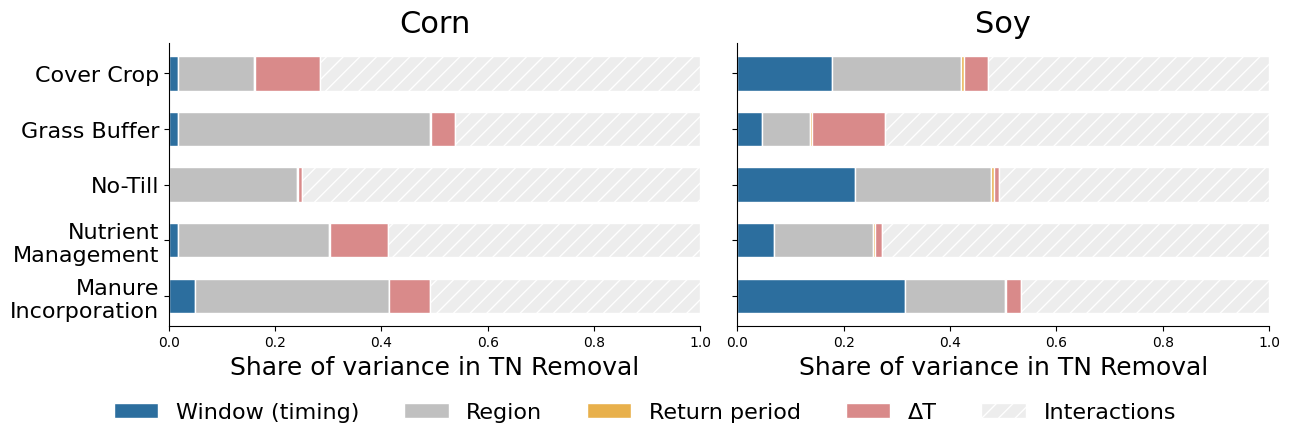

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# configuration
CORN_FILE = '/path/to/synthetic_corn_results.csv'
SOY_FILE  = '/path/to/synthetic_soy_results.csv'
OUTFIG    = "/outpath/to/synthetic_fig_variance_twopanel.png"

FLOOR  = 10      # baseline-load floor (base_TN)
POL    = "RE_TN"

BMP    = ["cc","gb","nt","nm","ma"]
BMPlab = {"cc":"Cover Crop","gb":"Grass Buffer","nm":"Nutrient\nManagement","nt":"No-Till","ma":"Manure\nIncorporation"}
fac    = ["window","region","return_period","dT"]
flab   = ["Window (timing)","Region","Return period","ΔT"]
fcol   = ["#2c6e9e","#c0c0c0","#e8b04b","#d98a8a"]

def eta(d, f): # share of RE variance from one factor
    g = d[POL].mean(); sst = ((d[POL]-g)**2).sum()
    if sst <= 0: return np.nan
    return d.groupby(f)[POL].apply(lambda x: ((x.mean()-g)**2)*len(x)).sum()/sst

def load_and_clean(filepath):
    """Helper to keep data parsing dry and consistent across both crops."""
    df = pd.read_csv(filepath)
    df = df[df[POL].notna() & (df.base_TN >= FLOOR)]
    return df[df.window.isin(["preplant","midseason"])]

# Load datasets
datasets = {
    "Corn": load_and_clean(CORN_FILE),
    "Soy": load_and_clean(SOY_FILE)
}

# plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, (crop_name, bal) in zip(axes, datasets.items()):
    left = np.zeros(len(BMP))
    
    # plot main factors
    for f, fl, c in zip(fac, flab, fcol):
        vals = np.array([eta(bal[bal.bmp==b], f) for b in BMP])
        ax.barh(range(len(BMP)), vals, left=left, color=c, label=fl,
                edgecolor="white", height=0.62)
        left += vals
        
    # plot interactions 
    ax.barh(range(len(BMP)), np.clip(1-left, 0, None), left=left, color="#ededed",
            hatch="//", edgecolor="white", height=0.62, label="Interactions")
    
    # styling
    ax.set_title(crop_name, fontsize=22, pad=8)
    ax.set_xlim(0, 1)
    ax.set_xlabel(f"Share of variance in TN Removal", fontsize=18)
    for sp in ["top","right"]: 
        ax.spines[sp].set_visible(False)

# y-axis format
axes[0].set_yticks(range(len(BMP)))
axes[0].set_yticklabels([BMPlab[b] for b in BMP], fontsize=16)
axes[0].invert_yaxis()

# legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=5, frameon=False, loc="lower center", 
           bbox_to_anchor=(0.5, -0.12), fontsize=16)

plt.tight_layout()
fig.savefig(OUTFIG, dpi=300, bbox_inches="tight")
plt.show()

### Other

#### Spin-up

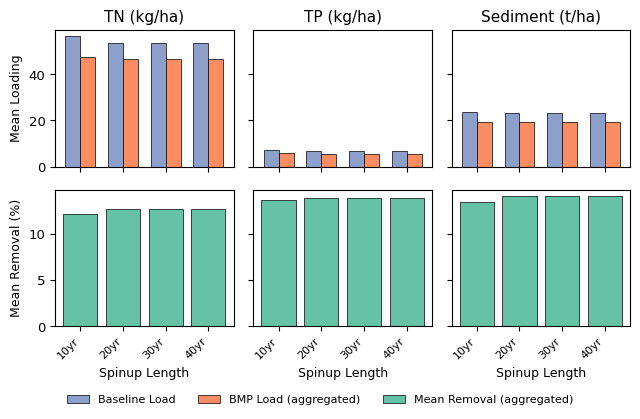

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# configuration
re_files = {
    "10yr": # path to 10 year spinup config,
    "20yr": # etc ,
    "30yr": "",
    "40yr": "",
}

re_metrics = ["RE_TN", "RE_TP", "RE_MUSL"]
load_metrics = ["TN", "TP", "MUSL"]


def clean_re(df, re_metrics):
    df = df.copy()
    for m in re_metrics:
        df[m] = pd.to_numeric(df[m], errors='coerce').replace([np.inf, -np.inf], np.nan)
    alive = (df['YLDG'] > 0) | (df['YLDF'] > 0)
    return df[alive]


# get stats
configs = list(re_files.keys())
base_loads = {m: [] for m in load_metrics}
bmp_loads = {m: [] for m in load_metrics}
mean_re = {m: [] for m in re_metrics}

for label, path in re_files.items():
    df = pd.read_csv(path)
    df = clean_re(df, re_metrics)

    base = df[df['bmp'] == 'base']
    bmp = df[df['bmp'] != 'base']

    for m in load_metrics:
        base_loads[m].append(base[m].mean())
        bmp_loads[m].append(bmp[m].mean())

    for m in re_metrics:
        valid = df[m].abs() < 200
        mean_re[m].append(df.loc[valid, m].mean())


# plot
fig, axes = plt.subplots(2, 3, figsize=(6.5, 4), sharex='col', sharey='row')
x = np.arange(len(configs))

colors_base = "#8da0cb"
colors_re = "#66c2a5"
colors_bmp = "#fc8d62"

units = {"TN": "kg/ha", "TP": "kg/ha", "MUSL": "t/ha"}

# Top row: loads (base vs BMP)
labels = {"TN": "TN (kg/ha)", "TP": "TP (kg/ha)", "MUSL": "Sediment (t/ha)"}
for i, m in enumerate(load_metrics):
    ax = axes[0, i]
    w = 0.35
    ax.bar(x - w/2, base_loads[m], w, color=colors_base, label="Baseline", edgecolor="black", linewidth=0.5)
    ax.bar(x + w/2, bmp_loads[m], w, color=colors_bmp, label="BMP (all)", edgecolor="black", linewidth=0.5)
    if i == 0:
        ax.set_ylabel(f"Mean Loading", fontsize=9)
    ax.set_title(f"{labels[m]}", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(configs, rotation=45, ha="right", fontsize=8)

# Bottom row: mean RE
for i, m in enumerate(re_metrics):
    ax = axes[1, i]
    ax.bar(x, mean_re[m], color=colors_re, edgecolor="black", linewidth=0.5)
    # add y-label only to first plot
    if i == 0:
        ax.set_ylabel("Mean Removal (%)", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(configs, rotation=45, ha="right", fontsize=8)
    #add value labels
    # for j, v in enumerate(mean_re[m]):
    #     ax.text(j, v + 0.2, f"{v:.1f}%", ha="center", va="bottom", fontsize=7)
    ax.set_xlabel("Spinup Length", fontsize=9)

# legend
legend_elements = [
    Patch(facecolor=colors_base, edgecolor="black", lw=0.5, label="Baseline Load"),
    Patch(facecolor=colors_bmp, edgecolor="black", lw=0.5, label="BMP Load (aggregated)"),
    Patch(facecolor=colors_re, edgecolor="black", lw=0.5, label="Mean Removal (aggregated)")
]

fig.legend(
    handles=legend_elements, 
    frameon=False, 
    loc="lower center", 
    ncol=3, 
    fontsize=8, 
    bbox_to_anchor=(0.5, -0.05)
)
plt.tight_layout()
plt.savefig(output_root + "spinup_loads_and_re.png", dpi=300)
plt.show()

#### Mechanisms: Soluble vs Particulate

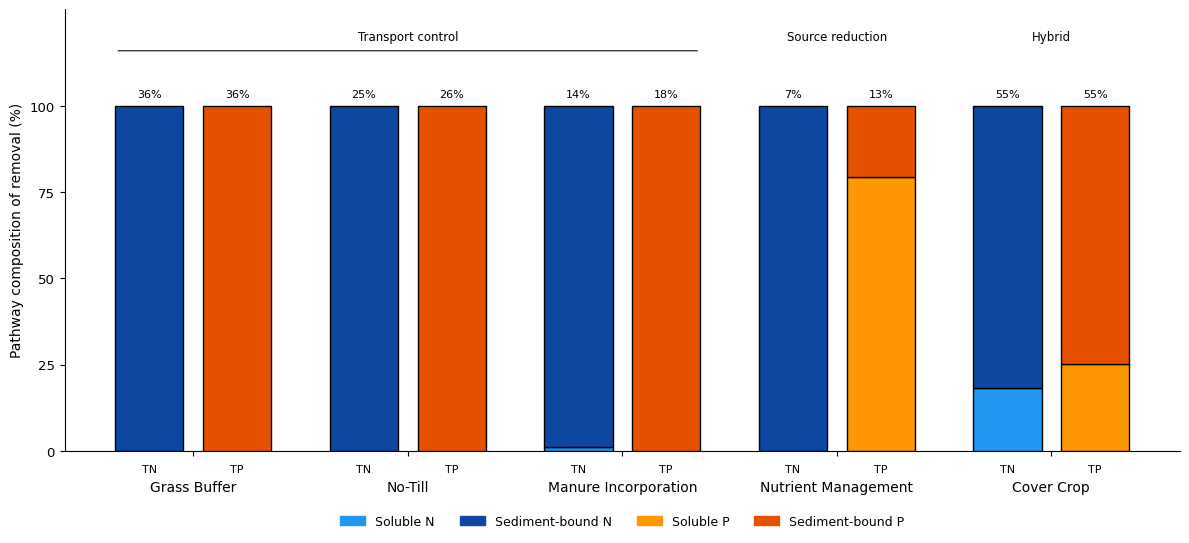

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# load data
df = pd.read_csv('/path/to/all_annual_results.csv')
df = df.drop(columns=[c for c in df.columns if c.startswith('Unnamed')])

def re_table(bmp_label, base_label):
    b = df[df['bmp'] == bmp_label]
    base = (df[df['bmp'] == base_label]
            [['scenario','crop','region','year','QN','YN','QP','YP','YLDG','YLDF']]
            .rename(columns={'QN':'b_QN','YN':'b_YN','QP':'b_QP','YP':'b_YP',
                             'YLDG':'b_YLDG','YLDF':'b_YLDF'}))
    m = b.merge(base, on=['scenario','crop','region','year'], how='inner')
    keep = (m['YLDG'] + m['YLDF'] != 0) & (m['b_YLDG'] + m['b_YLDF'] != 0)
    return m[keep]

baseline = {'gb':'base', 'nt':'base', 'nm':'base', 'cc':'base', 'ma':'ma-base'}
bmps = pd.concat([re_table(b, base) for b, base in baseline.items()],
                 ignore_index=True)

# per-fraction efficiency
for p, bp in [('QN','b_QN'), ('YN','b_YN'), ('QP','b_QP'), ('YP','b_YP')]:
    bmps[f'RE_{p}'] = ((bmps[bp] - bmps[p]) / bmps[bp] * 100).replace([np.inf,-np.inf], np.nan)
# real total efficiency (mass) for the magnitude annotation
bmps['b_TN'], bmps['TN'] = bmps.b_QN + bmps.b_YN, bmps.QN + bmps.YN
bmps['b_TP'], bmps['TP'] = bmps.b_QP + bmps.b_YP, bmps.QP + bmps.YP
bmps['RE_TN'] = ((bmps.b_TN - bmps.TN) / bmps.b_TN * 100).replace([np.inf,-np.inf], np.nan)
bmps['RE_TP'] = ((bmps.b_TP - bmps.TP) / bmps.b_TP * 100).replace([np.inf,-np.inf], np.nan)

med = bmps.groupby('bmp')[['RE_QN','RE_YN','RE_QP','RE_YP','RE_TN','RE_TP']].median()

def shares(sol, sed):
    s, y = max(sol, 0), max(sed, 0)      # negatives = not removing -> 0 share
    t = s + y
    return (np.nan, np.nan) if t == 0 else (s/t*100, y/t*100)

# style
bmp_order  = ['gb', 'nt', 'ma', 'nm', 'cc']
bmp_labels = {'gb':'Grass Buffer', 'nt':'No-Till', 'nm':'Nutrient Management',
              'ma':'Manure Incorporation', 'cc':'Cover Crop'}
c_solN, c_sedN, c_solP, c_sedP = '#2196F3', '#0D47A1', '#FF9800', '#E65100'

group_gap = 2.2
bar_w     = 0.7
off       = {'TN': -0.45, 'TP': 0.45}
group_centers = np.arange(len(bmp_order)) * group_gap

# plot
fig, ax = plt.subplots(figsize=(12, 5.5))

for b_idx, bmp in enumerate(bmp_order):
    gc = group_centers[b_idx]

    # TN composition
    sN, yN = shares(med.loc[bmp,'RE_QN'], med.loc[bmp,'RE_YN'])
    x = gc + off['TN']
    if not np.isnan(sN):
        ax.bar(x, sN, bar_w, color=c_solN, edgecolor='black', zorder=3)
        ax.bar(x, yN, bar_w, bottom=sN, color=c_sedN, edgecolor='black', zorder=3)
    ax.text(x, 102, f"{med.loc[bmp,'RE_TN']:.0f}%", ha='center', va='bottom', fontsize=8)
    ax.text(x, -4, 'TN', ha='center', va='top', fontsize=8)

    # TP composition
    sP, yP = shares(med.loc[bmp,'RE_QP'], med.loc[bmp,'RE_YP'])
    x = gc + off['TP']
    if not np.isnan(sP):
        ax.bar(x, sP, bar_w, color=c_solP, edgecolor='black', zorder=3)
        ax.bar(x, yP, bar_w, bottom=sP, color=c_sedP, edgecolor='black', zorder=3)
    ax.text(x, 102, f"{med.loc[bmp,'RE_TP']:.0f}%", ha='center', va='bottom', fontsize=8)
    ax.text(x, -4, 'TP', ha='center', va='top', fontsize=8)

# ── Mechanism brackets ────────────────────────────────────────────────────────
by = 116
bkw = dict(arrowprops=dict(arrowstyle='-', color='black', lw=0.75), annotation_clip=False)

ax.annotate('', xy=(group_centers[0]-0.8, by), xytext=(group_centers[2]+0.8, by), **bkw)
ax.text(np.mean(group_centers[:3]), by+2, 'Transport control', ha='center', va='bottom', fontsize=8.5)

ax.text(np.mean(group_centers[3]), by+2, 'Source reduction', ha='center', va='bottom', fontsize=8.5)

ax.text(group_centers[4], by+2, 'Hybrid', ha='center', va='bottom', fontsize=8.5)

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xticks(group_centers)
ax.set_xticklabels([bmp_labels[b] for b in bmp_order], fontsize=10)
ax.tick_params(axis='x', pad=18)
ax.set_ylabel('Pathway composition of removal (%)', fontsize=10)
ax.set_ylim(0, 128)
ax.set_yticks([0, 25, 50, 75, 100])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

handles = [mpatches.Patch(color=c_solN, label='Soluble N'),
           mpatches.Patch(color=c_sedN, label='Sediment-bound N'),
           mpatches.Patch(color=c_solP, label='Soluble P'),
           mpatches.Patch(color=c_sedP, label='Sediment-bound P')]
ax.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.2), frameon=False, fontsize=9, ncol=4)


plt.tight_layout()
plt.savefig(output_root + 'figure_pathway_composition.png',dpi=300, bbox_inches='tight')
plt.show()